MLP with training schedulers

In [1]:
# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import pandas
import torch
import pandas as pd
import numpy as np
from torch import nn, optim
import Training_options
device = Training_options.assess_device()
print(device)

cpu


In [ ]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import time

In [ ]:
PROJECT_DIR = Path.cwd()
PREPARED_DIR = PROJECT_DIR / "outputs" / "prepared_notebook"
RUN_DIR = PROJECT_DIR / "outputs" / "training_options" 

In [ ]:
lookBack = 28
maxStores = None
historyStart = None
trainStride = 7
epochs = 50
l2_lambda = 1e-4
l1_lambda = 1e-5
patience = 4
#MLP
BatchSize = 1024

In [5]:
data_dict = Training_options.read_split(test = os.path.join(PREPARED_DIR,"test_prepared.csv"), train = os.path.join(PREPARED_DIR,"train_prepared.csv"), valid = os.path.join(PREPARED_DIR,"validation_prepared.csv"), device=device)

In [6]:
train_df = data_dict["traindf"]
val_df = data_dict["valdf"]
test_df = data_dict["testdf"]
selectedStores = data_dict["selectedStores"]
eligibleStores = data_dict["eligibleStores"]
horizon = data_dict["Horizon"]
valDates = data_dict["valDates"]
testDates = data_dict["testDates"]
fullPreparedtestRows = data_dict["fullPreparedtestRows"]
categorical_features = data_dict["categoricalFeatures"]
numeric_features = data_dict["numericalFeatures"]

display(pd.DataFrame([
    {"split": name, "rows": len(frame), "stores": frame["Store"].nunique(),
     "start": frame["Date"].min().date(), "end": frame["Date"].max().date()}
    for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]
]))

print(f"Selected {len(selectedStores)} of {len(eligibleStores)} eligible stores.")
print(f"Training Hroeizon: {horizon} days; validation: {len(valDates)}; test: {len(testDates)}.")
print(f"Test coverage: {len(test_df):,} / {fullPreparedtestRows:,} prepared rows.")

,split,rows,stores,start,end
0,train,737279,856,2013-01-01,2015-06-19
1,validation,35952,856,2015-06-20,2015-07-31
2,test,41088,856,2015-08-01,2015-09-17


Selected 856 of 856 eligible stores.
Training Hroeizon: 48 days; validation: 42; test: 48.
Test coverage: 41,088 / 41,088 prepared rows.


In [7]:
numeric_means = train_df[numeric_features].astype(float).mean().fillna(0.0)
numeric_stds = train_df[numeric_features].astype(float).std(ddof=0).replace(0, 1).fillna(1.0)
category_levels = {
    col: sorted(train_df[col].fillna("missing").astype(str).unique().tolist())
    for col in categorical_features
}
store_to_index = {int(store): i for i, store in enumerate(selectedStores)}
train_log_sales = np.log1p(train_df["Sales"].to_numpy(dtype=np.float64))
sales_mean = float(train_log_sales.mean())
sales_std = max(float(train_log_sales.std()), 1e-6)

encoded_feature_names = numeric_features.copy()
for col, levels in category_levels.items():
    encoded_feature_names.extend([f"{col}={level}" for level in levels] + [f"{col}=unknown"])

print("Features per future day:", len(encoded_feature_names))
print("Features per historical day:", len(encoded_feature_names) + 1)
print("Log-sales training mean/std:", round(sales_mean, 3), round(sales_std, 3))

Features per future day: 47
Features per historical day: 48
Log-sales training mean/std: 7.251 3.317


Training windows: 95384
Skipped windows crossing missing dates: 1800
One history: (28, 48)
One future feature block: (48, 47)
One target block: (48,)


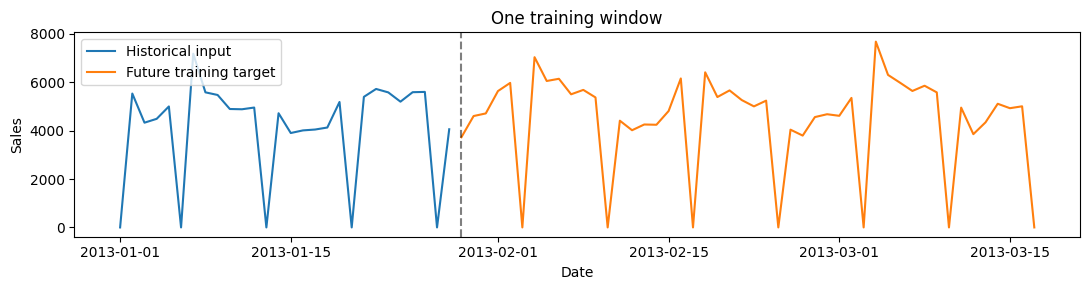

In [8]:

train_dataset = Training_options.SalesWindowDataset(train_df, lookBack, horizon, trainStride, store_to_index, numeric_features, numeric_means, category_levels, numeric_stds, sales_mean, sales_std)

example_history, example_future, example_store, example_target = train_dataset[0]
print("Training windows:", len(train_dataset))
print("Skipped windows crossing missing dates:", train_dataset.skipped_windows)
print("One history:", tuple(example_history.shape))
print("One future feature block:", tuple(example_future.shape))
print("One target block:", tuple(example_target.shape))

store_id, start = train_dataset.windows[0]
history, _, target, dates = train_dataset.series[store_id]
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(dates[start - lookBack:start], np.expm1(history[start - lookBack:start, 0] * sales_std + sales_mean),
        label="Historical input")
ax.plot(dates[start:start + horizon], np.expm1(target[start:start + horizon] * sales_std + sales_mean),
        label="Future training target")
ax.axvline(dates[start], color="black", linestyle="--", alpha=0.5)
ax.set(title="One training window", xlabel="Date", ylabel="Sales")
ax.legend()
fig.tight_layout()
plt.show()

In [9]:
val_inputs, val_rows = Training_options.make_forecast_inputs(train_df, val_df.drop(columns="Sales"), horizon, lookBack, store_to_index,
                                                             numeric_features,numeric_means, category_levels, numeric_stds,
                                                             sales_mean, sales_std)
val_labels = val_rows[["Store", "Date"]].merge(
    val_df[["Store", "Date", "Sales"]], on=["Store", "Date"],
    how="left", validate="one_to_one", sort=False
)["Sales"].to_numpy()
assert np.isfinite(val_labels).all()
print("Validation input shapes:", [tuple(tensor.shape) for tensor in val_inputs])
print("Last historical date:", valDates[0] - pd.Timedelta(days=1))
print("First forecast date:", valDates[0])

Validation input shapes: [(856, 28, 48), (856, 42, 47), (856,)]
Last historical date: 2015-06-19 00:00:00
First forecast date: 2015-06-20 00:00:00


# MLP

In [ ]:
category_maps = {}
category_cardinalities = {}
for column in categorical_features:
    values = sorted(Training_options.as_category_text(train_df[column]).unique())
    mapping = {"unknown": 0}
    mapping.update({value: index + 1 for index, value in enumerate(values)})
    category_maps[column] = mapping
    category_cardinalities[column] = len(mapping)

train_cat = Training_options.encode_categorical_frame(train_df, categorical_features, category_maps)
val_cat = Training_options.encode_categorical_frame(val_df, categorical_features, category_maps)
test_cat = Training_options.encode_categorical_frame(test_df, categorical_features, category_maps)

category_summary = pd.DataFrame(
    {
        "feature": list(category_cardinalities.keys()),
        "n_categories_including_unknown": list(category_cardinalities.values()),
    }
)

display(category_summary)

train_num = Training_options.scale_numeric_frame(train_df, numeric_features, numeric_means, numeric_stds)
val_num = Training_options.scale_numeric_frame(val_df, numeric_features, numeric_means, numeric_stds)
test_num = Training_options.scale_numeric_frame(test_df, numeric_features, numeric_means, numeric_stds)

display(train_num.head())

train_dataset = Training_options.StoreSalesDataset(train_cat, train_num, train_log_sales)
val_log_sales = np.log1p(val_df["Sales"].to_numpy(dtype=np.float64))
val_dataset = Training_options.StoreSalesDataset(val_cat, val_num, val_log_sales)
test_dataset = Training_options.StoreSalesDataset(test_cat, test_num)

train_loader = Training_options.make_dataloader(train_dataset, batch_size=BatchSize, shuffle=True)
val_loader = Training_options.make_dataloader(val_dataset, batch_size=BatchSize, shuffle=False)
test_loader = Training_options.make_dataloader(test_dataset, batch_size=BatchSize, shuffle=False)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

embedding_cardinalities = [category_cardinalities[column] for column in categorical_features]
embedding_dimensions = [Training_options.embedding_size(cardinality) for cardinality in embedding_cardinalities]

print("Embedding cardinalities:", embedding_cardinalities)
print("Embedding dimensions:", embedding_dimensions)

In [ ]:
model = Training_options.TabularSalesModel_MLP(embedding_cardinalities=embedding_cardinalities, 
                                               embedding_dimensions= embedding_dimensions, 
                                               n_numeric_features= len(numeric_features), dropout=0.15)
model.to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adamw(params= model.parameters(), lr = 0.01, weight_decay=l2_lambda)
scheduler = Training_options.create_scheduler(optimizer)

m_res, hist, b_ep = Training_options.mlp_basic_training_loop(model, train_loader, loss_function, optimizer,
                                                            epochs, val_loader, scheduler, l1_lambda, patience,
                                                            0.001, 2, os.path.join(RUN_DIR, "mlp_scheduler.pt"),device)

In [ ]:
print(hist["train_loss"])
print(hist["valid_loss"])
print(hist["valid_mae"])

In [ ]:
plt.plot(hist["train_loss"], label="Train")
plt.plot(hist["valid_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
m_res.eval()

predictions = []

with torch.inference_mode():
    for categorical_inputs, numeric_inputs in test_loader:
        categorical_inputs = categorical_inputs.to(device)
        numeric_inputs = numeric_inputs.to(device)

        preds = m_res(categorical_inputs, numeric_inputs)
        predictions.extend(preds.squeeze(-1).cpu().numpy())

test_predictions = pd.DataFrame({
    "Date": test_df["Date"].values,
    "Sales": predictions
})

test_predictions["Sales"] = test_predictions["Sales"].clip(lower=0)

display(test_predictions.head())

plt.figure(figsize=(12, 5))

plt.plot(
    test_predictions["Date"],
    test_predictions["Sales"]
)

plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.title("MLP Test Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()